In [3]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df = pd.read_excel('/content/student_data_final.xlsx')

print("Sample of data:\n", df.head())

Sample of data:
   assessment_type  weight  date_submitted  score  date_registration gender  \
0             TMA    10.0              18     78             -159.0      M   
1             TMA    10.0              22     70              -53.0      F   
2             TMA    10.0              17     72              -52.0      F   
3             TMA    10.0              26     69             -176.0      F   
4             TMA    10.0              19     79             -110.0      M   

                 region      highest_education imd_band age_band  \
0   East Anglian Region       HE Qualification  90-100%     55<=   
1              Scotland       HE Qualification   20-30%    35-55   
2     South East Region  A Level or Equivalent   50-60%    35-55   
3  West Midlands Region     Lower Than A Level   50-60%     0-35   
4                 Wales  A Level or Equivalent   80-90%    35-55   

   num_of_prev_attempts  studied_credits disability  \
0                     0              240          

In [4]:

df1=df.copy()

categorical_cols = ['assessment_type', 'gender', 'region', 'highest_education',
                    'imd_band', 'age_band', 'disability', 'final_result']

# Initializing label encoder
le = LabelEncoder()


for col in categorical_cols:
    df1[col] = le.fit_transform(df1[col])


print("\nEncoded data sample:\n", df1.head())



Encoded data sample:
    assessment_type  weight  date_submitted  score  date_registration  gender  \
0                2    10.0              18     78             -159.0       1   
1                2    10.0              22     70              -53.0       0   
2                2    10.0              17     72              -52.0       0   
3                2    10.0              26     69             -176.0       0   
4                2    10.0              19     79             -110.0       1   

   region  highest_education  imd_band  age_band  num_of_prev_attempts  \
0       0                  1         9         2                     0   
1       6                  1         2         1                     0   
2       7                  0         5         1                     0   
3      11                  2         5         0                     0   
4      10                  0         8         1                     0   

   studied_credits  disability  module_presentation

In [5]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = df1[['final_result']]
y = df1['date_registration']


X_train = X[y.notnull()]
y_train = y[y.notnull()]


model = LinearRegression()
model.fit(X_train, y_train)


y_pred = model.predict(X)


r2 = r2_score(y_train, model.predict(X_train))


print(f"R-squared: {r2}")

R-squared: 0.00042602713447637


In [6]:
# Imputing null values in 'date_registration' using predicted values
df1.loc[df1['date_registration'].isnull(), 'date_registration'] = y_pred[df1['date_registration'].isnull()]

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

def train_and_evaluate_models(df1, final_result):



    X = df1.drop(final_result, axis=1)
    y = df1[final_result]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


    models = {
        "Logistic Regression": LogisticRegression(),
        "Decision Tree": DecisionTreeClassifier(),
        "Random Forest": RandomForestClassifier(),

    }


    results = {}
    for model_name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        results[model_name] = accuracy
        print(f"--- {model_name} ---")
        print(f"Accuracy: {accuracy}")
        print(classification_report(y_test, y_pred))

    best_model = max(results, key=results.get)
    print(f"\nBest Model: {best_model} with accuracy {results[best_model]}")

    return results, best_model


results, best_model_name  = train_and_evaluate_models(df1, 'final_result')

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


--- Logistic Regression ---
Accuracy: 0.6139432914352528
              precision    recall  f1-score   support

           0       0.36      0.02      0.03      5135
           1       0.47      0.07      0.12      5613
           2       0.62      0.98      0.76     20829
           3       0.34      0.05      0.09      2633

    accuracy                           0.61     34210
   macro avg       0.45      0.28      0.25     34210
weighted avg       0.54      0.61      0.50     34210

--- Decision Tree ---
Accuracy: 0.5558316281788951
              precision    recall  f1-score   support

           0       0.42      0.45      0.43      5135
           1       0.33      0.36      0.35      5613
           2       0.70      0.68      0.69     20829
           3       0.23      0.24      0.24      2633

    accuracy                           0.56     34210
   macro avg       0.42      0.43      0.43     34210
weighted avg       0.56      0.56      0.56     34210

--- Random Forest ---


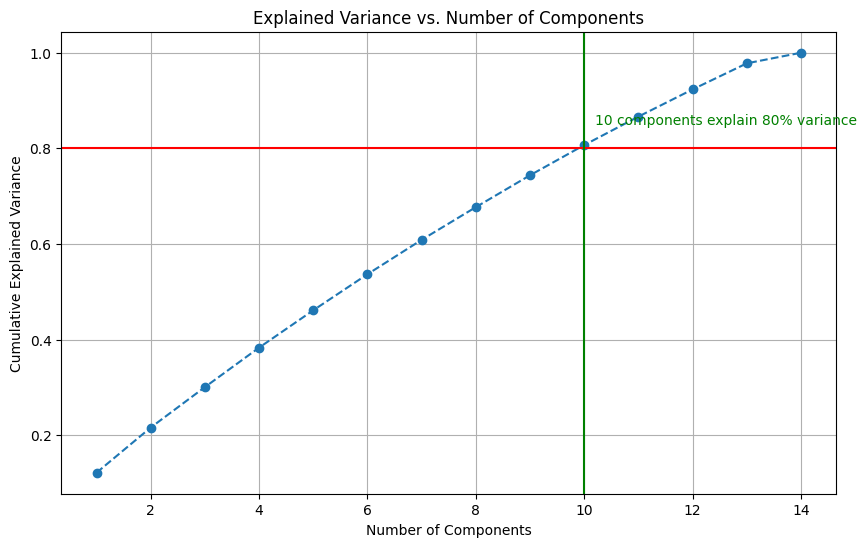

In [9]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt




X = df1.drop('final_result', axis=1)
y = df1['final_result']


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


pca = PCA()
pca.fit(X_scaled)
explained_variance_ratios = pca.explained_variance_ratio_


cumulative_variance = np.cumsum(explained_variance_ratios)

# Number of components for 80% variance
n_components_80 = np.argmax(cumulative_variance >= 0.80) + 1

# 6. Plot the variance graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.title('Explained Variance vs. Number of Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.axhline(y=0.80, color='r', linestyle='-')
plt.axvline(x=n_components_80, color='g', linestyle='-')
plt.text(n_components_80 + 0.2, 0.85, f'{n_components_80} components explain 80% variance', color='g')
plt.grid(True)
plt.show()

In [14]:
pca = PCA(n_components=n_components_80)
X_pca = pca.fit_transform(X_scaled)


df_pca = pd.DataFrame(X_pca, columns=[f"PC{i+1}" for i in range(X_pca.shape[1])])

df1_final = pd.concat([df_pca, y], axis=1)


In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


X = df1_final.drop('final_result', axis=1)
y = df1_final['final_result']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(X_train, y_train)


y_pred = rf_classifier.predict(X_test)


print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.29      0.42      5135
           1       0.62      0.31      0.42      5613
           2       0.68      0.95      0.79     20829
           3       0.63      0.12      0.21      2633

    accuracy                           0.68     34210
   macro avg       0.68      0.42      0.46     34210
weighted avg       0.68      0.68      0.63     34210



In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


X = df1_final.drop('final_result', axis=1)
y = df1_final['final_result']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


logreg_model = LogisticRegression(random_state=42, max_iter=1000)
logreg_model.fit(X_train, y_train)


y_pred = logreg_model.predict(X_test)


print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.50      0.01      0.03      5135
           1       0.44      0.08      0.14      5613
           2       0.62      0.98      0.76     20829
           3       0.32      0.01      0.02      2633

    accuracy                           0.61     34210
   macro avg       0.47      0.27      0.24     34210
weighted avg       0.55      0.61      0.49     34210



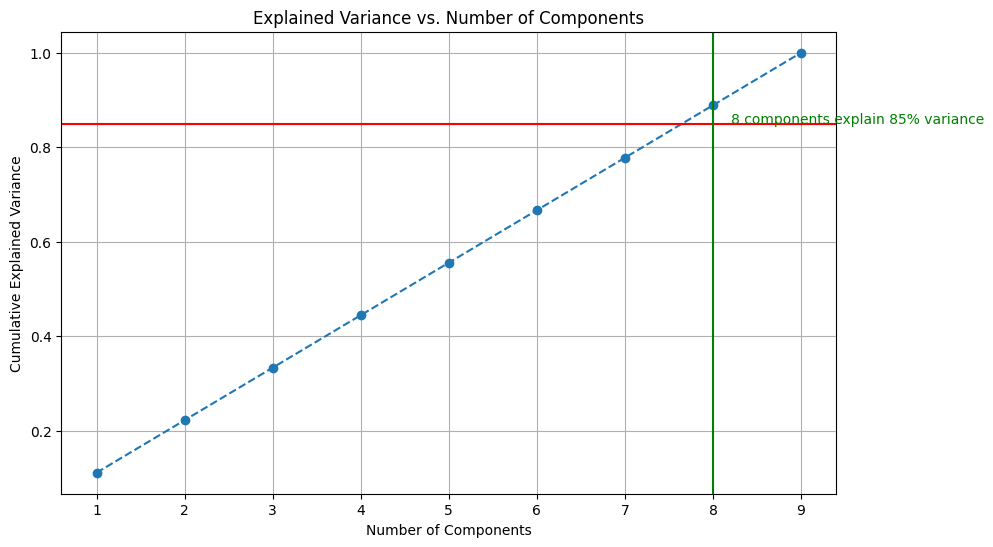

In [25]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


pca = PCA()
pca.fit(X_scaled)
explained_variance_ratios = pca.explained_variance_ratio_


cumulative_variance = np.cumsum(explained_variance_ratios)

# Number of components for 85% variance
n_components_85 = np.argmax(cumulative_variance >= 0.85) + 1

# 6. Plot the variance graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.title('Explained Variance vs. Number of Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.axhline(y=0.85, color='r', linestyle='-')
plt.axvline(x=n_components_85, color='g', linestyle='-')
plt.text(n_components_85 + 0.2, 0.85, f'{n_components_85} components explain 85% variance', color='g')
plt.grid(True)
plt.show()

In [26]:
pca = PCA(n_components=n_components_85)
X_pca = pca.fit_transform(X_scaled)


df_pca = pd.DataFrame(X_pca, columns=[f"PC{i+1}" for i in range(X_pca.shape[1])])

df1_final = pd.concat([df_pca, y], axis=1)


In [27]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


X = df1_final.drop('final_result', axis=1)
y = df1_final['final_result']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(X_train, y_train)


y_pred = rf_classifier.predict(X_test)


print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.22      0.34      5135
           1       0.64      0.27      0.38      5613
           2       0.67      0.96      0.79     20829
           3       0.63      0.10      0.18      2633

    accuracy                           0.67     34210
   macro avg       0.68      0.39      0.42     34210
weighted avg       0.68      0.67      0.61     34210



In [28]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


X = df1_final.drop('final_result', axis=1)
y = df1_final['final_result']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


logreg_model = LogisticRegression(random_state=42, max_iter=1000)
logreg_model.fit(X_train, y_train)


y_pred = logreg_model.predict(X_test)


print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.33      0.00      0.01      5135
           1       0.42      0.04      0.08      5613
           2       0.62      0.99      0.76     20829
           3       0.32      0.01      0.02      2633

    accuracy                           0.61     34210
   macro avg       0.42      0.26      0.22     34210
weighted avg       0.52      0.61      0.48     34210



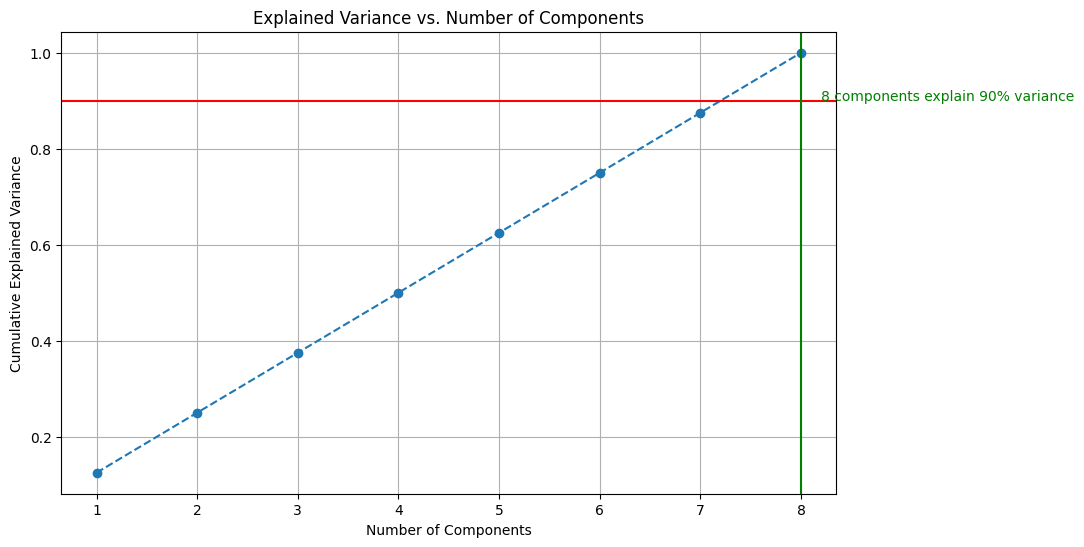

In [29]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


pca = PCA()
pca.fit(X_scaled)
explained_variance_ratios = pca.explained_variance_ratio_


cumulative_variance = np.cumsum(explained_variance_ratios)

# Number of components for 90% variance
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1

# 6. Plot the variance graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.title('Explained Variance vs. Number of Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.axhline(y=0.90, color='r', linestyle='-')
plt.axvline(x=n_components_90, color='g', linestyle='-')
plt.text(n_components_90 + 0.2, 0.90, f'{n_components_90} components explain 90% variance', color='g')
plt.grid(True)
plt.show()

In [30]:
pca = PCA(n_components=n_components_85)
X_pca = pca.fit_transform(X_scaled)


df_pca = pd.DataFrame(X_pca, columns=[f"PC{i+1}" for i in range(X_pca.shape[1])])

df1_final = pd.concat([df_pca, y], axis=1)


In [31]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


X = df1_final.drop('final_result', axis=1)
y = df1_final['final_result']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


logreg_model = LogisticRegression(random_state=42, max_iter=1000)
logreg_model.fit(X_train, y_train)


y_pred = logreg_model.predict(X_test)


print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.33      0.00      0.01      5135
           1       0.42      0.04      0.08      5613
           2       0.62      0.99      0.76     20829
           3       0.32      0.01      0.02      2633

    accuracy                           0.61     34210
   macro avg       0.42      0.26      0.22     34210
weighted avg       0.52      0.61      0.48     34210



In [32]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


X = df1_final.drop('final_result', axis=1)
y = df1_final['final_result']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(X_train, y_train)


y_pred = rf_classifier.predict(X_test)


print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.21      0.33      5135
           1       0.63      0.27      0.38      5613
           2       0.67      0.96      0.79     20829
           3       0.62      0.10      0.18      2633

    accuracy                           0.67     34210
   macro avg       0.67      0.39      0.42     34210
weighted avg       0.67      0.67      0.60     34210



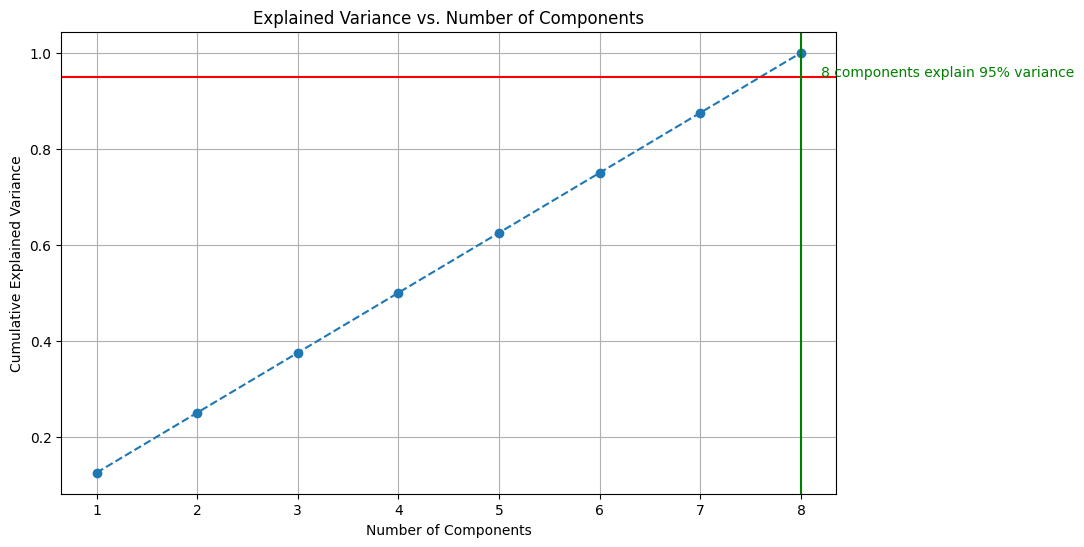

In [34]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


pca = PCA()
pca.fit(X_scaled)
explained_variance_ratios = pca.explained_variance_ratio_


cumulative_variance = np.cumsum(explained_variance_ratios)

# Number of components for 95% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

# 6. Plot the variance graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.title('Explained Variance vs. Number of Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.axhline(y=0.95, color='r', linestyle='-')
plt.axvline(x=n_components_95, color='g', linestyle='-')
plt.text(n_components_95 + 0.2, 0.95, f'{n_components_95} components explain 95% variance', color='g')
plt.grid(True)
plt.show()